In [1]:
import matplotlib.pyplot as plt

from modules.dataset import PanoramaDataset
from modules.panorama import split_panorama
from modules.lvlm import QwenVLBackend
from modules.descriptions import DescriptionStore

{'panoid': '2ar5YEfUFbX8AFv6lTT51A', 'pano_lat': '56.21652264980573', 'pano_lon': '10.28951380687832', 'image_path': 'images/shard_000000.tar::2ar5YEfUFbX8AFv6lTT51A_360.jpg'}


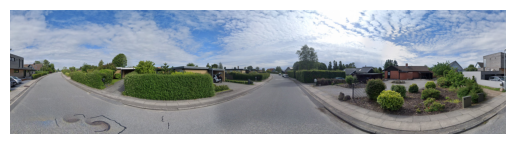

In [2]:
################################
# Load Panorama from dataset
################################

dataset = PanoramaDataset(
    dataset_root="test_dataset", 
    shuffle=False,
    exclude_columns=[
        "pano_date",
        "query_lat",
        "query_lon",
        "snap_distance_m",
        "source",
        "source_value",
        "image_type",
        "yaw",
        "pitch",
        "fov"
    ],
)

image, metadata = next(iter(dataset))

print(metadata)

plt.imshow(image)
plt.axis("off")
plt.show()

Index: 0
Height: 768, Width: 768


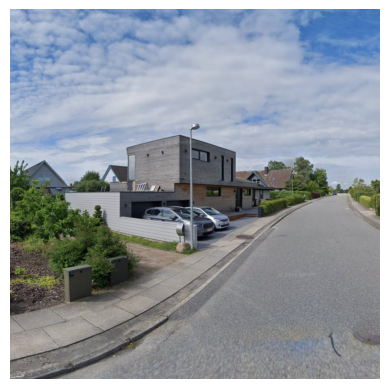

In [4]:
################################
# Split Panorama into 6 subimages
################################

subimages = split_panorama(image)

print(f'Index: {subimages[0].subimage_index}')
print(f'Height: {subimages[0].image.height}, Width: {subimages[0].image.width}')

plt.imshow(subimages[0].image)
plt.axis("off")
plt.show()

In [5]:

################################
# Describe the image with lvlm
################################

image = subimages[0].image
prompt = "Describe this image"

backend = QwenVLBackend(
    model_name="cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit",
    tensor_parallel_size=1,
    gpu_memory_utilization=0.75,
    max_model_len=1024,
    dtype="auto",
)

response = backend.generate(
    image=image,
    prompt=prompt,
    max_tokens=128,
    temperature=0.1,
    top_p=0.95,
    repetition_penalty=1.0,
)

print(response)

INFO 09-12 17:53:36 [api_utils.py:286] non-default args: {'tokenizer': 'cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', 'trust_remote_code': True, 'max_model_len': 1024, 'gpu_memory_utilization': 0.75, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 1, 'video': 0}, 'mm_processor_cache_gb': 0, 'model': 'cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit'}
INFO 09-12 17:53:36 [model.py:684] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 09-12 17:53:36 [model.py:2021] Using max model len 1024
WARNING 09-12 17:53:37 [model.py:981] Model does not support mm_device_do_normalize, forcing mm_device_do_normalize = False.
INFO 09-12 17:53:38 [scheduler.py:277] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-12 17:53:38 [kernel.py:369] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


(EngineCore pid=2268123) INFO 09-12 17:53:44 [core.py:123] Initializing a V1 LLM engine (v0.29.0) with config: model='cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', speculative_config=None, tokenizer='cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=1024, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=compressed-tensors, quantization_config=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_h

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


(EngineCore pid=2268123) INFO 09-12 17:53:47 [default_loader.py:430] Loading weights took 1.20 seconds
(EngineCore pid=2268123) INFO 09-12 17:53:48 [model_runner.py:404] Model loading took 4.52 GiB memory and 3.435847 seconds
(EngineCore pid=2268123) INFO 09-12 17:53:48 [topk_topp_sampler.py:62] Using FlashInfer for top-p & top-k sampling.
(EngineCore pid=2268123) INFO 09-12 17:53:48 [utils.py:306] Using LBNHC KV cache layout.
(EngineCore pid=2268123) INFO 09-12 17:53:49 [encoder_runner.py:131] Encoder cache will be initialized with a budget of 16384 tokens, and profiled with 1 image items of the maximum feature size.
(EngineCore pid=2268123) INFO 09-12 17:53:59 [caching.py:343] reconstructed serializable fn from standalone compile artifacts. num_artifacts=5 num_submods=37
(EngineCore pid=2268123) INFO 09-12 17:53:59 [decorators.py:313] Directly load AOT compilation from path /home/Daniel6702/.cache/vllm/torch_compile_cache/torch_aot_compile/ee1370c402e477daaf667e398764a48e59388634fcdf

...

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:01<00:00, 27.59it/s]


(EngineCore pid=2268123) INFO 09-12 17:54:13 [model_runner.py:960] Graph capturing finished in 6 secs, took 0.22 GiB
(EngineCore pid=2268123) INFO 09-12 17:54:13 [gpu_worker.py:797] CUDA graph pool memory: 0.22 GiB (actual), 0.44 GiB (estimated), difference: 0.22 GiB (100.7%).
(EngineCore pid=2268123) INFO 09-12 17:54:13 [gpu_worker.py:860] Free memory on device (9.45/11.59 GiB) on startup. Desired GPU memory utilization is (0.75, 8.69 GiB). Actual usage is 4.93 GiB for consumed memory (weights + non-torch), 2.37 GiB for peak activation, and 0.22 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=1095843328` (1.02 GiB) to fit into requested memory, or `--kv-cache-memory=1906867712` (1.78 GiB) to fully utilize gpu memory. Current kv cache memory in use is 1.39 GiB.
(EngineCore pid=2268123) INFO 09-12 17:54:14 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=2268123) INFO

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it, est. speed input: 532.41 toks/s, output: 115.70 toks/s]

LVLMResponse(text='This is a daytime street-level photograph of a modern, two-story house in a suburban neighborhood, under a partly cloudy sky.\n\nKey details:\n- **Architecture**: The house has a contemporary design with a gray, possibly wood-paneled or concrete facade. It features clean lines, large windows, and a flat roof. A prominent garage with a white, horizontal siding facade is attached to the lower level.\n- **Surroundings**: The house is set back from the road, with a paved driveway and sidewalk. Two cars are parked in the garage: a silver SUV and a silver sedan. The property is landscaped with green shrubs and', model_name='cyankiwi/Qwen3-VL-4B-Instruct-AWQ-4bit', prompt='Describe this image')


In [ ]:
################################
# Store description in database. And retrieve it again.
################################

panoid = metadata["panoid"]
subimage = subimages[0]
prompt_index = 0            #incase more than one prompt per image
description = response.text

with DescriptionStore("test_dataset/descriptions.sqlite") as store:
    store.add_many([
        (panoid, subimage.subimage_index, prompt_index, description),
    ])

    description = store.get(
        panoid=panoid,
        subimage_index=subimage.subimage_index,
        prompt_index=prompt_index,
    )

    print("Description:")
    print(description)


Description:
This is a daytime street-level photograph of a modern, two-story house in a suburban neighborhood, under a partly cloudy sky.

Key details:
- **Architecture**: The house has a contemporary design with a gray, possibly wood-paneled or concrete facade. It features clean lines, large windows, and a flat roof. A prominent garage with a white, horizontal siding facade is attached to the lower level.
- **Surroundings**: The house is set back from the road, with a paved driveway and sidewalk. Two cars are parked in the garage: a silver SUV and a silver sedan. The property is landscaped with green shrubs and
